In [1]:
import os
import json
import itertools
import copy
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
font1 = {"weight": "bold", "size": 18}

## Calculate the median of the increase and decrease LMP

In [64]:
# read the base case results
sweep_result_path = os.path.join(os.getcwd(), "Sweep_summary")
df_base = pd.read_csv(os.path.join(sweep_result_path , "Summarized_sweep_base_case.csv"))
mkt = "LMP DA"

In [65]:
def calculate_corr(delta_lmp, gap=4.9):
    pos_delta_list = []
    neg_delta_list = []
    
    for i in range(len(delta_lmp)):
        if delta_lmp[i] > gap:
            pos_delta_list.append(delta_lmp[i])
        if delta_lmp[i] < -1*gap:
            neg_delta_list.append(delta_lmp[i])
    
    # plt.scatter(tot_da_load[idx_list], tot_da_renew[idx_list], marker='.')
    
    # pos_correlation_coefficient, p_value = pearsonr(tot_da_load[pos_idx_list], tot_da_renew[pos_idx_list])
    # pos_correlation_coefficient, p_value

    # neg_correlation_coefficient, p_value = pearsonr(tot_da_load[neg_idx_list], tot_da_renew[neg_idx_list])
    # neg_correlation_coefficient, p_value

    return pos_delta_list, neg_delta_list

In [66]:
# for idx in list(sweep_record.keys())[0]:
#     csv_index = f"{idx}_{sweep_record[idx]['pem_pmax_ratio']}_{sweep_record[idx]['pem_bid']}"
#     file_path = os.path.join(sweep_result_path, f"Summarized_sweep_{csv_index}.csv")
#     df_res = pd.read_csv(file_path)
#     lmp_da_arr = df_res["LMP DA"].to_numpy()
#     delta_lmp = lmp_da_arr - base_lmp_da_arr
#     plt.hist(delta_lmp)

In [67]:
# read the sweep data
col_name = "Dispatch DA"
base_lmp_da_arr = df_base['LMP DA'].to_numpy()

res_summary = {}
res_summary['positive_med'] = {}
res_summary['negative_med'] = {}

pem_bid = list(range(5, 50, 5))  
pem_ratio = list(i/10 for i in range(1, 11, 1))
rows = len(pem_bid) # pem bid
cols = len(pem_ratio) # pem ratio

with open(os.path.join(sweep_result_path, "sweep_record.json"), "r") as f:
    sweep_record = json.load(f)

for idx in list(sweep_record.keys()):
    csv_index = f"{idx}_{sweep_record[idx]['pem_pmax_ratio']}_{sweep_record[idx]['pem_bid']}"
    file_path = os.path.join(sweep_result_path, f"Summarized_sweep_{csv_index}.csv")
    df_res = pd.read_csv(file_path)
    lmp_da_arr = df_res["LMP DA"].to_numpy()
    delta_lmp = lmp_da_arr - base_lmp_da_arr
    # data_ = df_res[col_name].to_numpy()
    pos_delta_list, neg_delta_list  = calculate_corr(delta_lmp, gap=2)
    res_summary['positive_med'][idx] = np.median(pos_delta_list)
    res_summary['negative_med'][idx] = np.median(neg_delta_list)

array([[ 6.1805465,  7.6137885,  4.799911 ,  4.825977 ,  4.858561 ,
         4.882934 ,  4.899558 ,  4.912272 ,  4.922129 ,  4.929995 ],
       [ 5.9650065,  9.48526  ,  9.835717 ,  9.883852 ,  9.907808 ,
         9.923434 ,  9.934531 ,  9.942818 ,  9.949243 ,  9.95437  ],
       [ 6.679978 ,  9.49075  , 12.625081 , 14.935279 , 14.950757 ,
        14.959101 , 14.967896 , 14.972723 , 14.975787 , 14.979622 ],
       [ 5.613131 ,  9.694596 , 12.5571545, 16.266114 , 16.970947 ,
        18.134365 , 18.573789 , 18.573789 , 18.861019 , 19.034775 ],
       [ 5.2144945,  8.9500265, 11.4044255, 12.513756 , 12.4636635,
        13.818151 , 11.170732 , 11.648023 ,  7.277122 ,  4.652308 ],
       [ 4.683585 ,  6.7619845,  6.415137 ,  5.580016 ,  4.7975065,
         3.841438 ,  3.558339 ,  3.409431 ,  3.300672 ,  3.342749 ],
       [ 4.6451385,  6.09861  ,  6.486573 ,  5.2979885,  4.336756 ,
         3.774194 ,  3.739215 ,  3.521846 ,  3.522828 ,  3.486508 ],
       [ 4.8650845,  6.113673 ,  6.934833

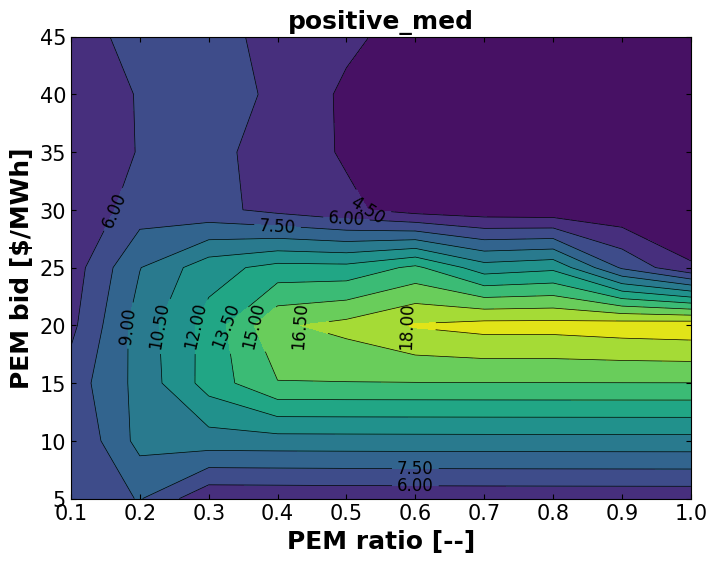

In [68]:
def make_contour(res_summary, col_name):
    pem_bid = list(range(5, 50, 5))  
    pem_ratio = list(i/10 for i in range(1, 11, 1))
    
    data_arr = np.zeros((len(pem_bid), len(pem_ratio)))
    
    for key in list(res_summary[col_name].keys()):
        ratio = sweep_record[key]['pem_pmax_ratio']
        bid = sweep_record[key]['pem_bid']
        i = pem_bid.index(bid)
        j = pem_ratio.index(ratio)
        data_arr[i][j] = res_summary[col_name][key]
        
    X, Y = np.meshgrid(pem_ratio, pem_bid)
    
    plt.figure(figsize=(8,6))
    
    # Create filled contour plot
    plt.contourf(X, Y, data_arr, levels=10, cmap='viridis')
    # Add contour lines on top
    ctl = plt.contour(X, Y, data_arr, levels=10, colors='black', linewidths=0.5)
    plt.clabel(ctl, inline=True, fontsize=12, fmt="%.2f")
    plt.tick_params(direction='in', top=True, right=True, labelsize = 15)
    plt.xlabel("PEM ratio [--]", font=font1)
    plt.ylabel("PEM bid [$/MWh]", font=font1)
    plt.title(f"{col_name}", font=font1)
    
    return data_arr

# make_contour(res_summary, 'negative')
make_contour(res_summary, 'positive_med')

array([[-4.204428 , -4.235022 , -4.035527 , -4.1510765, -4.087947 ,
        -4.007202 , -4.073156 , -4.2067355, -4.403698 , -4.294338 ],
       [-4.0297225, -4.0455235, -3.711832 , -4.25582  , -4.159126 ,
        -4.095336 , -4.5015475, -4.16476  , -4.603574 , -4.70897  ],
       [-3.7478   , -3.759633 , -3.927588 , -3.6595685, -3.622121 ,
        -3.637709 , -3.817481 , -3.782386 , -3.881096 , -3.879068 ],
       [-4.12894  , -3.642161 , -3.906859 , -3.970641 , -4.00425  ,
        -4.007202 , -4.071714 , -3.989176 , -4.151351 , -4.0060955],
       [-4.3496975, -4.186197 , -4.0687315, -4.572258 , -4.489244 ,
        -4.791857 , -5.080493 , -5.1617405, -5.258278 , -5.5092905],
       [-4.092542 , -4.093691 , -4.395729 , -4.589335 , -4.724242 ,
        -5.154056 , -5.387677 , -5.621572 , -6.264932 , -6.539691 ],
       [-4.056511 , -4.004926 , -3.880262 , -4.700372 , -5.183103 ,
        -5.453964 , -5.912363 , -6.165621 , -7.113021 , -7.8539735],
       [-4.533284 , -3.663635 , -3.831629

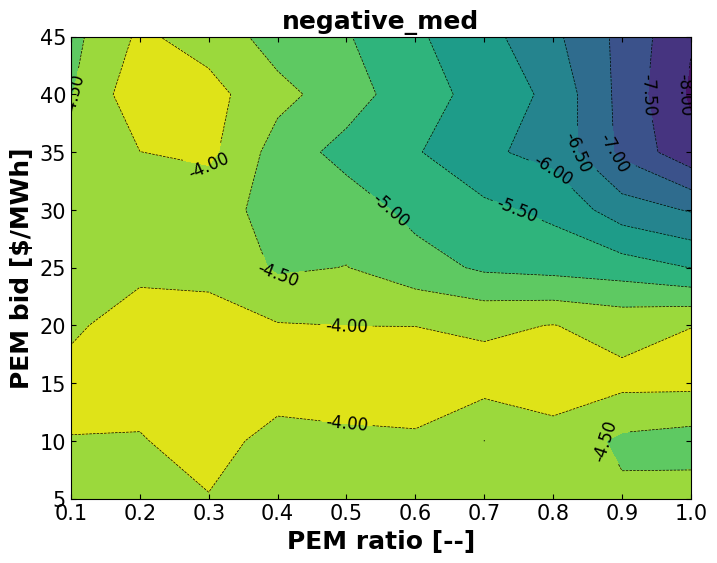

In [69]:
make_contour(res_summary, 'negative_med')

## Using PEM bid and PEM size to decide the level of increase and decrease

In [70]:
X = []
y_pos = []
y_neg = []
for idx in list(sweep_record.keys()):
    y_pos.append(res_summary['positive_med'][idx])
    y_neg.append(res_summary['negative_med'][idx])
    
    X_ = [sweep_record[idx]['pem_pmax_ratio'], sweep_record[idx]['pem_bid']]
    X.append(X_)

X = np.array(X)
y_pos = np.array(y_pos)
y_neg = np.array(y_neg)

### Linear Decision Tree 

In [71]:
from lineartree import LinearTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from pcm_utils import calculate_performance_metric

X_train, X_test, y_train, y_test = train_test_split(
    X, y_pos,      # data and target
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42      # for reproducibility
)

# scale the data
# lt_scaler_x = StandardScaler()
# X_train_scale = lt_scaler_x.fit_transform(X_train)
# X_test_scaled = lt_scaler_x.transform(X_test)
# lt_scaler_y_pos = StandardScaler()
# y_train_scale = lt_scaler_y_pos.fit_transform(y_train)
# y_test_scale = lt_scaler_y_pos.transform(y_test)

regr = LinearTreeRegressor(base_estimator=LinearRegression())

regr.fit(X_test, y_test)

y_test_pred = regr.predict(X_test)
y_train_pred = regr.predict(X_train)

calculate_performance_metric(y_test, y_test_pred, y_train, y_train_pred)

Train MAE: 2.5202
Train MSE: 3.339
Train R2: 0.4864
Test MAE: 0.2873
Test MSE: 0.4713
Test R2: 0.9869


In [72]:
# save the model

import pickle

with open('increase_lt_regr.pickle', 'wb') as handle1:
    pickle.dump(regr, handle1)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_neg,      # data and target
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42      # for reproducibility
)

regr = LinearTreeRegressor(base_estimator=LinearRegression())

regr.fit(X_train, y_train)

y_test_pred = regr.predict(X_test)
y_train_pred = regr.predict(X_train)

calculate_performance_metric(y_test, y_test_pred, y_train, y_train_pred)

Train MAE: 0.177
Train MSE: 0.2373
Train R2: 0.9527
Test MAE: 0.1657
Test MSE: 0.1974
Test R2: 0.9294


In [42]:
with open('decrease_lt_regr.pickle', 'wb') as handle1:
    pickle.dump(regr, handle1)

## Classification for entire dataset

### Read the feature data

### read the DA data for the entire grid

In [77]:
gmlc_path = os.path.join(os.getcwd(), "..", "..",  "..", "..", "..", "rts-gmlc", "RTS-GMLC", "RTS_Data", "timeseries_data_files")

# load
load_da_path = os.path.join(gmlc_path, "Load", "DAY_AHEAD_regional_Load.csv")
df_da_load = pd.read_csv(load_da_path)
tot_zone_1_da_load = df_da_load["1"].to_numpy()
tot_da_load = df_da_load["1"].to_numpy() + df_da_load["2"].to_numpy() + df_da_load["3"].to_numpy()

# csp
csp_da_path = os.path.join(gmlc_path, "CSP", "DAY_AHEAD_Natural_Inflow.csv")
df_da_csp = pd.read_csv(csp_da_path)
csp_da_arr = df_da_csp["212_CSP_1"].to_numpy()

# hydro
hydro_da_path = os.path.join(gmlc_path, "Hydro", "DAY_AHEAD_hydro.csv")
df_da_hydro = pd.read_csv(hydro_da_path)
tot_da_hydro = df_da_hydro[df_da_hydro.columns[4]]
for hydro in df_da_hydro.columns[5:]:
    tot_da_hydro += df_da_hydro[hydro]
hydro_da_arr = tot_da_hydro.to_numpy()

# pv
pv_da_path = os.path.join(gmlc_path, "PV", "DAY_AHEAD_pv.csv")
df_da_pv = pd.read_csv(pv_da_path)
tot_da_pv = df_da_pv[df_da_pv.columns[4]]
for pv in df_da_pv.columns[5:]:
    tot_da_pv += df_da_pv[pv]
pv_da_arr = tot_da_pv.to_numpy()
        
# RTPV
rtpv_da_path = os.path.join(gmlc_path, "RTPV", "DAY_AHEAD_rtpv.csv")
df_da_rtpv = pd.read_csv(rtpv_da_path)
tot_da_rtpv = df_da_rtpv[df_da_rtpv.columns[4]]
for rtpv in df_da_rtpv.columns[5:]:
    tot_da_rtpv += df_da_rtpv[rtpv]
rtpv_da_arr = tot_da_rtpv.to_numpy()

# wind
wind_da_path = os.path.join(gmlc_path, "WIND", "DAY_AHEAD_wind.csv")
df_da_wind = pd.read_csv(wind_da_path)
tot_da_wind = df_da_wind[df_da_wind.columns[4]] + df_da_wind[df_da_wind.columns[5]] + df_da_wind[df_da_wind.columns[6]] + df_da_wind[df_da_wind.columns[7]]
wind_da_arr = tot_da_wind.to_numpy()

tot_da_renew = csp_da_arr + hydro_da_arr + pv_da_arr + rtpv_da_arr + wind_da_arr

### read the DA data for zone 1

In [78]:
gmlc_path = os.path.join(os.getcwd(), "..", "..",  "..", "..", "..", "rts-gmlc", "RTS-GMLC", "RTS_Data", "timeseries_data_files")

# load
load_da_path = os.path.join(gmlc_path, "Load", "DAY_AHEAD_regional_Load.csv")
df_da_load = pd.read_csv(load_da_path)
tot_zone_1_da_load = df_da_load["1"].to_numpy()
tot_da_load = df_da_load["1"].to_numpy() + df_da_load["2"].to_numpy() + df_da_load["3"].to_numpy()

# hydro
hydro_da_path = os.path.join(gmlc_path, "Hydro", "DAY_AHEAD_hydro.csv")
df_da_hydro = pd.read_csv(hydro_da_path)
tot_da_hydro = df_da_hydro['122_HYDRO_1'] 
for hydro in ['122_HYDRO_2', '122_HYDRO_3', '122_HYDRO_4', '122_HYDRO_5', '122_HYDRO_6',]:
    tot_da_hydro += df_da_hydro[hydro]
hydro_da_arr = tot_da_hydro.to_numpy()

# pv
pv_da_path = os.path.join(gmlc_path, "PV", "DAY_AHEAD_pv.csv")
df_da_pv = pd.read_csv(pv_da_path)
tot_da_pv = df_da_pv['102_PV_1']
for pv in ['101_PV_1', '102_PV_2', '104_PV_1', '101_PV_2', '101_PV_3', '101_PV_4', '103_PV_1', '119_PV_1']:
    tot_da_pv += df_da_pv[pv]
pv_da_arr = tot_da_pv.to_numpy()
        
# RTPV
rtpv_da_path = os.path.join(gmlc_path, "RTPV", "DAY_AHEAD_rtpv.csv")
df_da_rtpv = pd.read_csv(rtpv_da_path)
tot_da_rtpv = df_da_rtpv['118_RTPV_1']
for rtpv in ['118_RTPV_2', '118_RTPV_3', '118_RTPV_4', '118_RTPV_5', '118_RTPV_6', '320_RTPV_6', '118_RTPV_7', '118_RTPV_8', '118_RTPV_9', '118_RTPV_10']:
    tot_da_rtpv += df_da_rtpv[rtpv]
rtpv_da_arr = tot_da_rtpv.to_numpy()

# wind
wind_da_path = os.path.join(gmlc_path, "WIND", "DAY_AHEAD_wind.csv")
df_da_wind = pd.read_csv(wind_da_path)
tot_da_wind = df_da_wind['122_WIND_1']
wind_da_arr = tot_da_wind.to_numpy()

tot_da_zone1_renew = hydro_da_arr + pv_da_arr + rtpv_da_arr + wind_da_arr

### Assemble X and y

In [79]:
gap = 2

X = []
y = []

# read each PCM.
for idx in list(sweep_record.keys()):
    csv_index = f"{idx}_{sweep_record[idx]['pem_pmax_ratio']}_{sweep_record[idx]['pem_bid']}"
    file_path = os.path.join(sweep_result_path, f"Summarized_sweep_{csv_index}.csv")
    df_res = pd.read_csv(file_path)
    lmp_da_arr = df_res["LMP DA"].to_numpy()
    dispatch_da_arr = df_res["Dispatch DA"].to_numpy()
    delta_lmp = lmp_da_arr - base_lmp_da_arr

    for i in range(len(delta_lmp)):
        # append features
        X.append([tot_da_load[i], tot_da_renew[i], dispatch_da_arr[i]/tot_da_load[i], base_lmp_da_arr[i]])
        if delta_lmp[i] > gap:
            y.append(2) # if increase, label is 2
        if delta_lmp[i] < -1*gap:
            y.append(0) # if decrease, label is 0
        if -1*gap <= delta_lmp[i] <= gap:
            y.append(1) # if unchanged, label is 1

np.shape(X), np.shape(y)

((790560, 4), (790560,))

### Build the decision tree classifier

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [16]:
# 1) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) Model (start simple; max_depth prevents overfitting)
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

# 3) Train
clf.fit(X_train, y_train)

# 4) Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8360149767253593
Confusion matrix:
 [[  3151   4423    237]
 [  2441 122949   2934]
 [   743  15150   6084]]
Report:
               precision    recall  f1-score   support

           0       0.50      0.40      0.45      7811
           1       0.86      0.96      0.91    128324
           2       0.66      0.28      0.39     21977

    accuracy                           0.84    158112
   macro avg       0.67      0.55      0.58    158112
weighted avg       0.82      0.84      0.81    158112



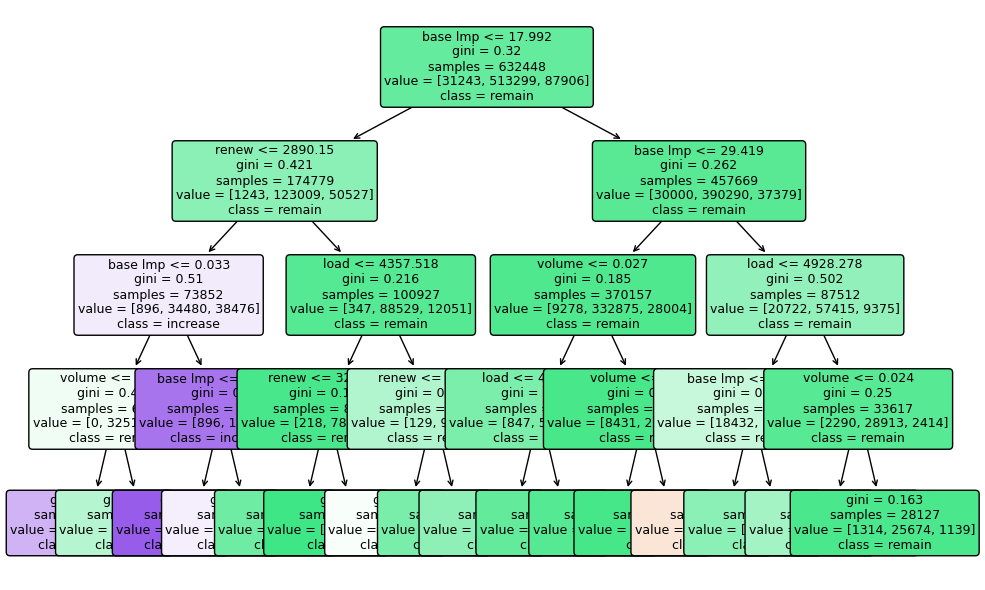

Feature importances: [0.13692358 0.30947528 0.13487667 0.41872446]


In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=['load', 'renew', 'volume', 'base lmp'], class_names=['decrease', 'remain', 'increase'],
          filled=True, rounded=True, fontsize=9)
plt.tight_layout()
plt.show()

print("Feature importances:", clf.feature_importances_)

### Build ANN classifier

In [46]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.losses import MeanSquaredError
from sklearn.preprocessing import MinMaxScaler
from pcm_utils import calculate_performance_metric
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [84]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42
)

# scale the data
classfication_scaler = StandardScaler()
X_train_scaled = classfication_scaler.fit_transform(X_train)
X_test_scaled = classfication_scaler.transform(X_test)

ann_clf = models.Sequential([
    layers.Dense(32, activation="relu", input_shape=(4,)),   # hidden layer 1
    layers.Dropout(0.2),                                     # dropout for regularization
    layers.Dense(16, activation="relu"),                     # hidden layer 2
    layers.Dense(3, activation="softmax")                    # output layer (3 classes)
])

ann_clf.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------
# Train
# -------------------------
history = ann_clf.fit(
    X_train_scaled, y_train,
    # validation_split=0.2,
    epochs=20,
    batch_size=256,
    verbose=1
)



Epoch 1/20
2471/2471 [==============================] - 5s 2ms/step - loss: 0.4649 - accuracy: 0.8204
Epoch 2/20
2471/2471 [==============================] - 4s 2ms/step - loss: 0.4061 - accuracy: 0.8350
Epoch 3/20
2471/2471 [==============================] - 4s 2ms/step - loss: 0.3940 - accuracy: 0.8396
Epoch 4/20
2471/2471 [==============================] - 3s 1ms/step - loss: 0.3882 - accuracy: 0.8417
Epoch 5/20
2471/2471 [==============================] - 5s 2ms/step - loss: 0.3850 - accuracy: 0.8434
Epoch 6/20
2471/2471 [==============================] - 4s 2ms/step - loss: 0.3829 - accuracy: 0.8439
Epoch 7/20
2471/2471 [==============================] - 4s 2ms/step - loss: 0.3811 - accuracy: 0.8447
Epoch 8/20
2471/2471 [==============================] - 3s 1ms/step - loss: 0.3800 - accuracy: 0.8452
Epoch 9/20
2471/2471 [==============================] - 3s 1ms/step - loss: 0.3787 - accuracy: 0.8455
Epoch 10/20
2471/2471 [==============================] - 4s 1ms/step - loss: 0.377

In [85]:
loss, acc = ann_clf.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

y_pred = ann_clf.predict(X_test_scaled)

Test accuracy: 0.850
4941/4941 [==============================] - 3s 656us/step


In [86]:
y_pred_decoded_int = np.argmax(y_pred, axis=1)
y_pred_decoded = encoder.inverse_transform(y_pred_decoded_int)

y_test_decoded_int = np.argmax(y_test, axis=1)
y_test_decoded = encoder.inverse_transform(y_test_decoded_int)


acc = accuracy_score(y_pred_decoded, y_test_decoded)

acc

0.8498532685691156

In [87]:
print("Confusion matrix:\n", confusion_matrix(y_pred_decoded, y_test_decoded))
print("Report:\n", classification_report(y_pred_decoded, y_test_decoded))

Confusion matrix:
 [[  3510   1645    914]
 [  4021 121709  11732]
 [   318   5110   9153]]
Report:
               precision    recall  f1-score   support

           0       0.45      0.58      0.50      6069
           1       0.95      0.89      0.92    137462
           2       0.42      0.63      0.50     14581

    accuracy                           0.85    158112
   macro avg       0.60      0.70      0.64    158112
weighted avg       0.88      0.85      0.86    158112



In [90]:
# Save the model
# ann_clf.save("ann_clf_model")

# save the scaling bounds for the parameters
classfication_scaler.mean_
offset_inputs = {}
offset_inputs['xm'] = classfication_scaler.mean_.tolist()
offset_inputs['xstd'] = classfication_scaler.var_.tolist()
offset_inputs['xmin'] =  np.min(X_train_scaled, axis=0).tolist()
offset_inputs['xmax'] =  np.max(X_train_scaled, axis=0).tolist()

with open("ann_clf_scaling_param.json", "w") as json_file:
    json.dump(offset_inputs, json_file)

## Build Logistics Regression classifier

In [81]:
from sklearn.linear_model import LogisticRegression
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the logistics regression model
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

acc

0.8147515685083991

In [82]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))

Confusion matrix:
 [[   303   7545      1]
 [   230 127934    300]
 [   190  21024    585]]
Report:
               precision    recall  f1-score   support

           0       0.42      0.04      0.07      7849
           1       0.82      1.00      0.90    128464
           2       0.66      0.03      0.05     21799

    accuracy                           0.81    158112
   macro avg       0.63      0.35      0.34    158112
weighted avg       0.78      0.81      0.74    158112



## SVM

In [83]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [27]:
# # Split data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # Build pipeline: scaling + SVM
# clf = Pipeline([
#     ("scaler", StandardScaler()),
#     ("svc", SVC(kernel="rbf", random_state=42))   # default params
# ])

# # Train
# clf.fit(X_train, y_train)

# # Predict
# y_pred = clf.predict(X_test)

# # Evaluate
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification report:\n", classification_report(y_test, y_pred))

# SVM is too difficule too train. (CPU time)